In [117]:
%reload_ext autoreload
%autoreload 2

import importlib

import numpy as np
import matplotlib.pyplot as plt
import state_to_edgepoints as state_to_edgepoints_module

state_to_edgepoints_module = importlib.reload(state_to_edgepoints_module)
state_to_edgepoints = state_to_edgepoints_module.state_to_edgepoints

import sys

# go out of folder to import the CR alg
sys.path.append("..")

from filters import ChristianRobinson 



from datetime import datetime
from dataclasses import dataclass
import pytz
from enum import Enum

from utils import circle_points, camera_view, noise
from classes import Camera, Body, PlanetImage, Pose


from InterfaceWrapperFuncs import Set_camera, gen_traj, plot_traj, get_images,run_step, get_tpc, plot_est_dist_xyz, plot_est_dist_xyz_errors

In [55]:
f, mu, n_pixels = Set_camera() #Sagitta camera parameters


# One-time calculation
camera = Camera(f, mu, n_pixels)
camera.calc_specs()
moon_radius = 1737.4 # km
moon_mu = 4902.800066 # km^3/s^2

body = Body(a=moon_radius, b=moon_radius, c=moon_radius)
#print(camera)
print(body)


w, h = 1280, 720
K = np.array(
    [
        [1120.0, 0.0, w / 2.0],
        [0.0, 1120.0, h / 2.0],
        [0.0, 0.0, 1.0],
    ],
    dtype=np.float64,
)

k_inv = np.linalg.inv(K)

camera_spec_ellie = {
    "K": K,
    "width": w,
    "height": h,
}

camera_spec_ellie2 = {
    "K": np.linalg.inv(camera.K_inv),
    "width": camera.resolution[0],
    "height": camera.resolution[1],
}

cr_alg = ChristianRobinson(k_inv, body.a, body.b, body.c)


Worldview:
 - Ellipsoid semi-axes a,b,c = [1737.4, 1737.4, 1737.4] km



Orbital period (T): 164927.14738070985s


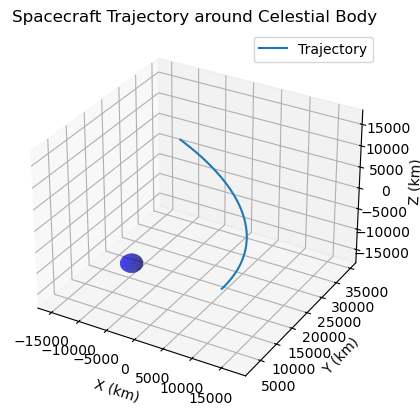

826
0


In [62]:
pos = np.array([15000, 400, 100])
r = np.linalg.norm(pos)
v = np.sqrt( moon_mu / r) + 0.2 # km/s, slightly
State0 = [pos[0], pos[1], pos[2], 0, v, 0] 



dt = 100
op, body_struct = gen_traj(Starting_state=State0, dt=dt)
plot_traj(op, body_struct)

print(len(op.states))
print(op.ts[0])


In [106]:
# for 10 points along traj gen images and test CR alg
cam_offset = np.array([5, 5, 0]) # no offset for now
images, edges, outs, states, times = get_images(op, body_struct, cam_offset, camera_spec_ellie, 5)


State at t=0.0s: [1.500e+04 4.000e+02 1.000e+02 0.000e+00 7.716e-01 0.000e+00]
State at t=20600.0s: [ 1.110e+04  1.492e+04  7.401e+01 -3.286e-01  6.010e-01 -2.191e-03]
State at t=41200.0s: [ 3.247e+03  2.511e+04  2.165e+01 -4.089e-01  4.024e-01 -2.726e-03]
State at t=61800.0s: [-5.214e+03  3.203e+04 -3.476e+01 -4.069e-01  2.800e-01 -2.713e-03]
State at t=82400.0s: [-1.340e+04  3.696e+04 -8.935e+01 -3.870e-01  2.036e-01 -2.580e-03]


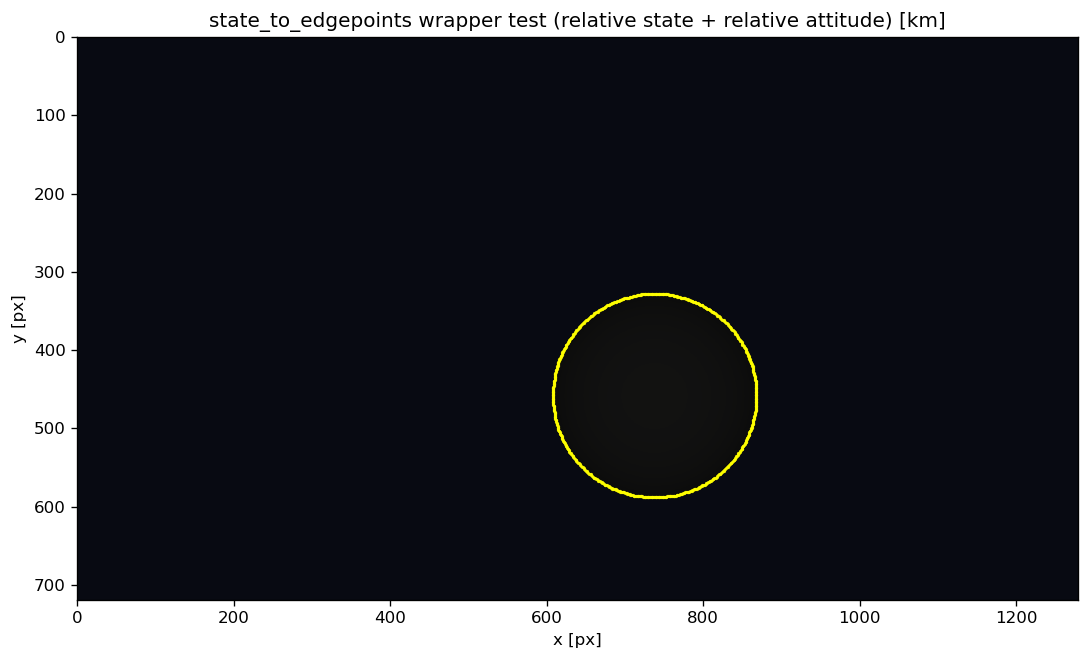

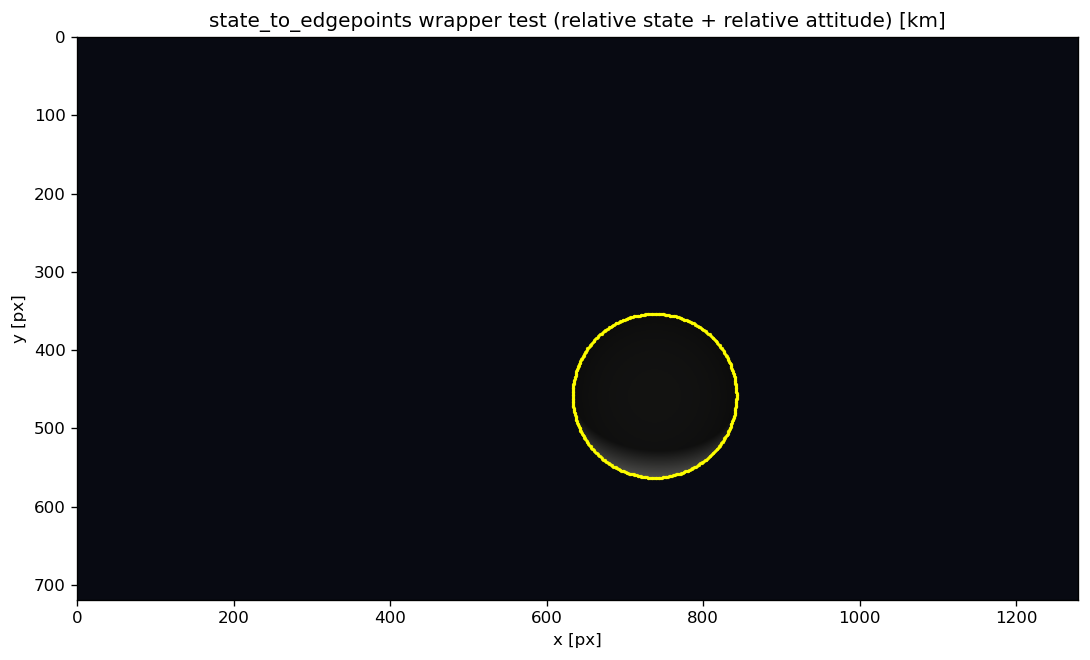

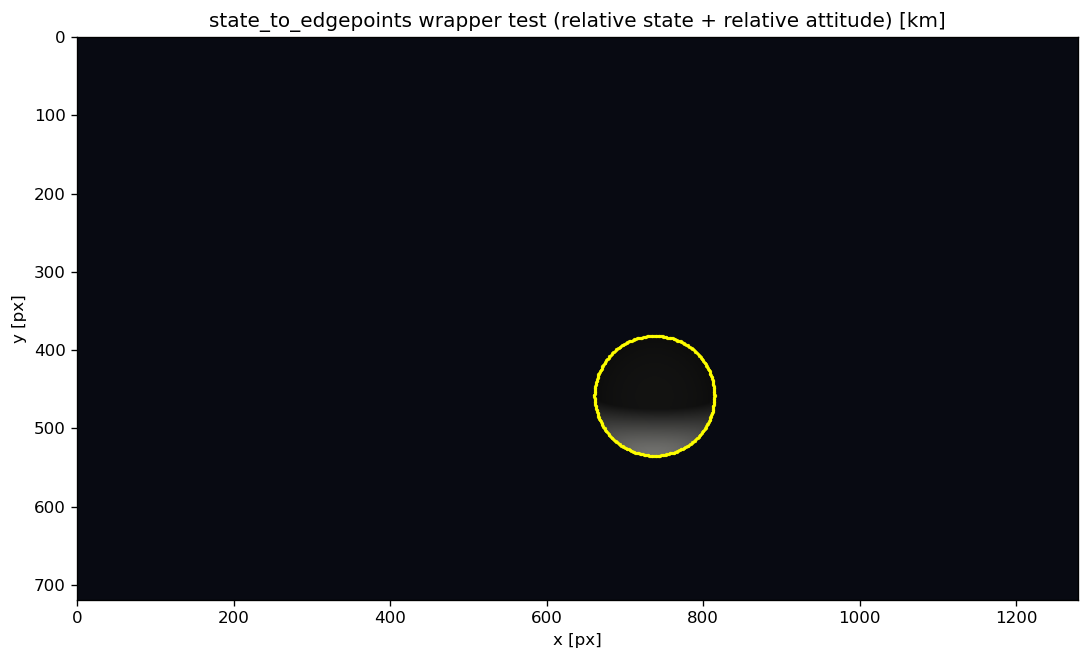

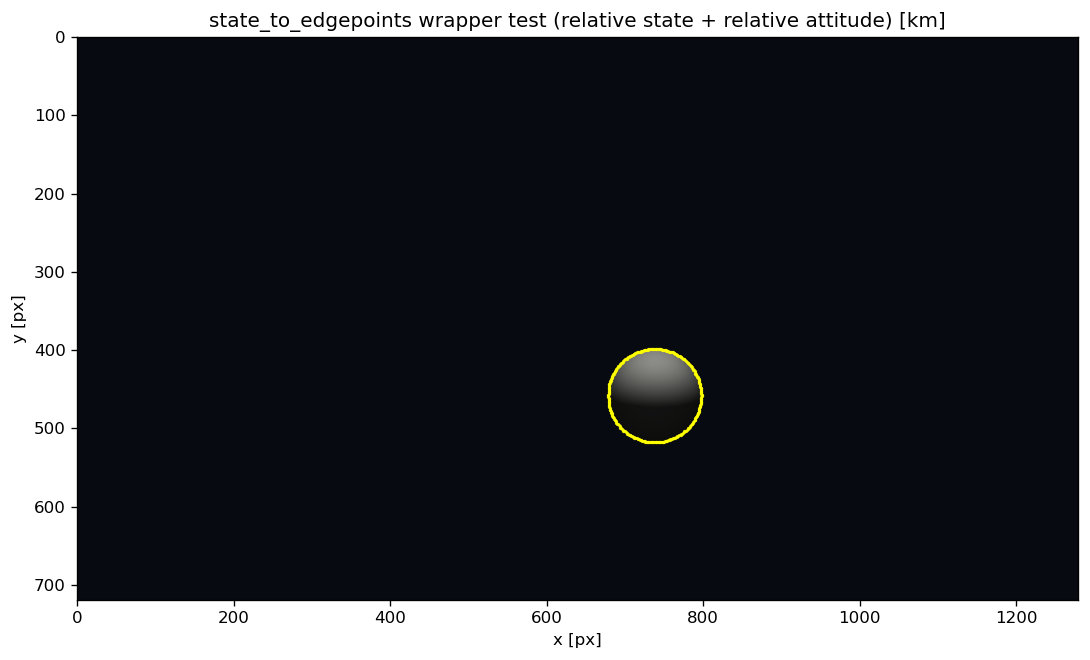

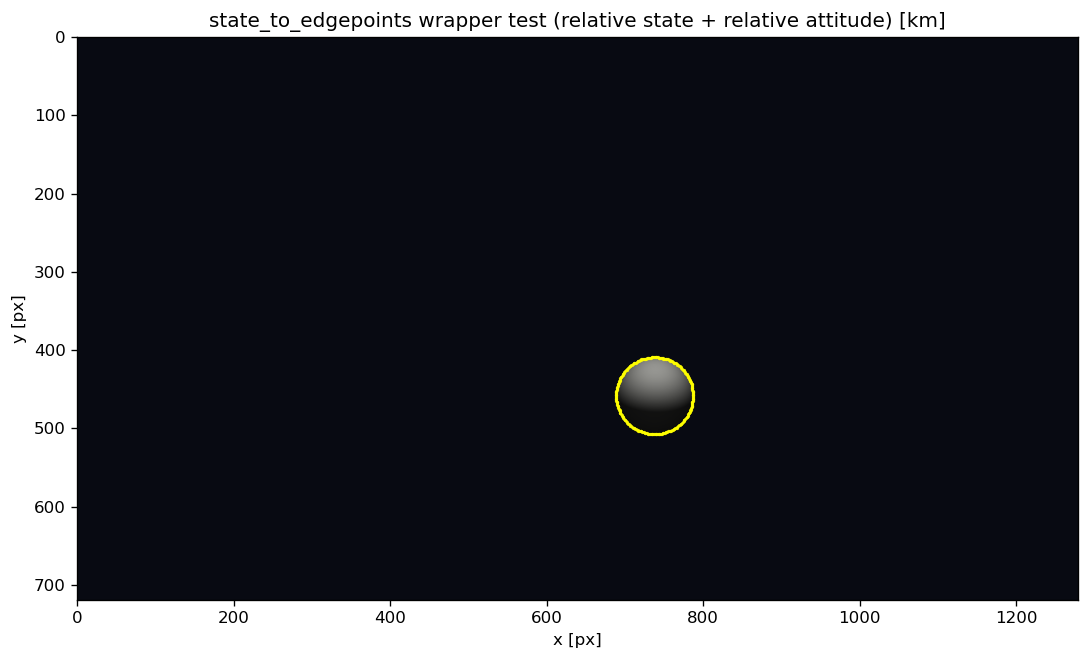

In [107]:
# plot the images and edge points with optional pixel-axis limits
x_limits = None  # e.g. (420, 860)
y_limits = None  # e.g. (560, 180) for image coordinates (inverted y)

for out in outs:
    w, h = camera_spec_ellie["width"], camera_spec_ellie["height"]
    state_to_edgepoints_module.plot_edge_points(
        out,
        w,
        h,
        x_limits=x_limits,
        y_limits=y_limits,
    )

In [114]:

# Running Christian-Robinson algorithm on all images
# Note: Camera offset is now handled in get_images() via attitude_offset_from_center_pointing

estimates = []
for i in range(len(outs)):
    print(f"Running CR alg on image {i+1}/{len(outs)}")
    out = outs[i]
    state = states[i]
    edge = edges[i]
    
    # Compute planet-to-camera rotation matrix from render output
    tpc = get_tpc(out)
    
    # Prepare edge points as homogeneous coordinates [x, y, 1]
    edge_homogeneous = np.hstack((edge, np.ones((edge.shape[0], 1))))

    # Run Christian-Robinson: estimates camera->planet vector in camera frame
    rc_est, rp_est = run_step(edge_homogeneous, state[0:3], tpc, print_stats=True, cr_alg=cr_alg)
    estimates.append(-rp_est)

Running CR alg on image 1/5
Calc Position:
 - (C->P in camera frame): [ 1304.96  1309.56 15114.95] (15227.60 km)
 - (C->P in planet frame): [-15222.41   -388.24    -84.12] (15227.60 km)
Actual position:
 - (C->P in camera frame): [ 1302.85  1307.83 14891.68] (15005.67 km)
 - (C->P in planet frame): [-15000.   -400.   -100.] (15005.67 km)
Est Error - Actual:
 - (Camera frame): [  2.1    1.73 223.27] (223.29 km)
 - (Planet frame): [-222.41   11.76   15.88] (223.29 km)
Distance error: 221.93 km (1.478973%)
Angular error: 0.0932 degrees
Running CR alg on image 2/5
Calc Position:
 - (C->P in camera frame): [ 1626.4   1632.41 18748.51] (18889.59 km)
 - (C->P in planet frame): [-11288.87 -15145.1     -61.43] (18889.59 km)
Actual position:
 - (C->P in camera frame): [ 1614.51  1620.67 18453.9 ] (18595.15 km)
 - (C->P in planet frame): [-11101.79 -14917.26    -74.01] (18595.15 km)
Est Error - Actual:
 - (Camera frame): [ 11.9   11.74 294.61] (295.08 km)
 - (Planet frame): [-187.08 -227.85   12.

(5, 3)
[  388.241 15145.101 25552.64  32654.155 37727.961]
times: [    0 20600 41200 61800 82400]


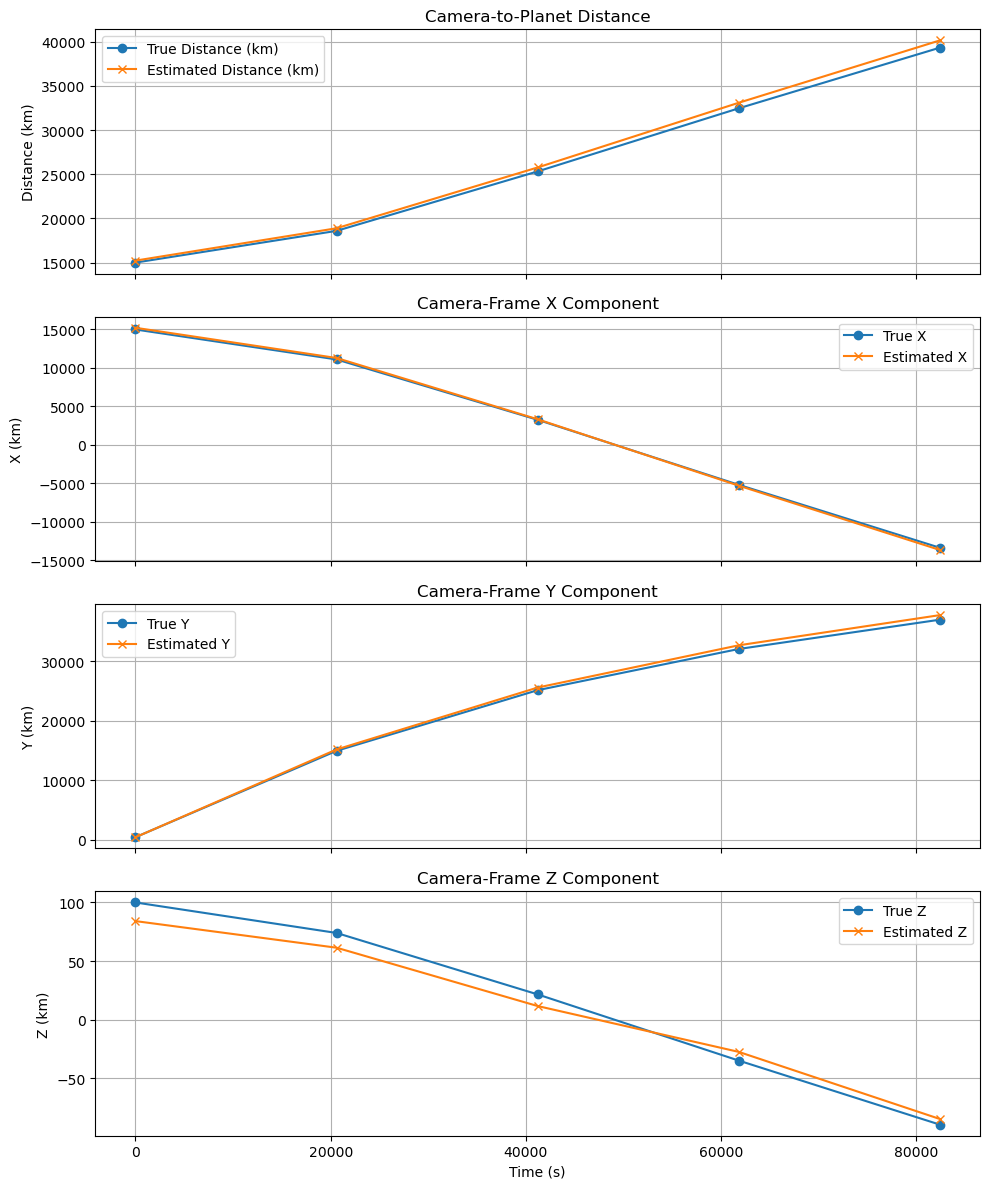

In [ ]:
# compare true/estimated camera-frame vectors and distances with optional axis limits
states = np.array(states)
pos = states[:, 0:3]
estimates = np.array(estimates)
times = np.array(times)

print(np.shape(pos))
print(estimates[:, 1])
print("times:", times)



plot_est_dist_xyz(
    times,
    pos,
    estimates,
    error= True
)

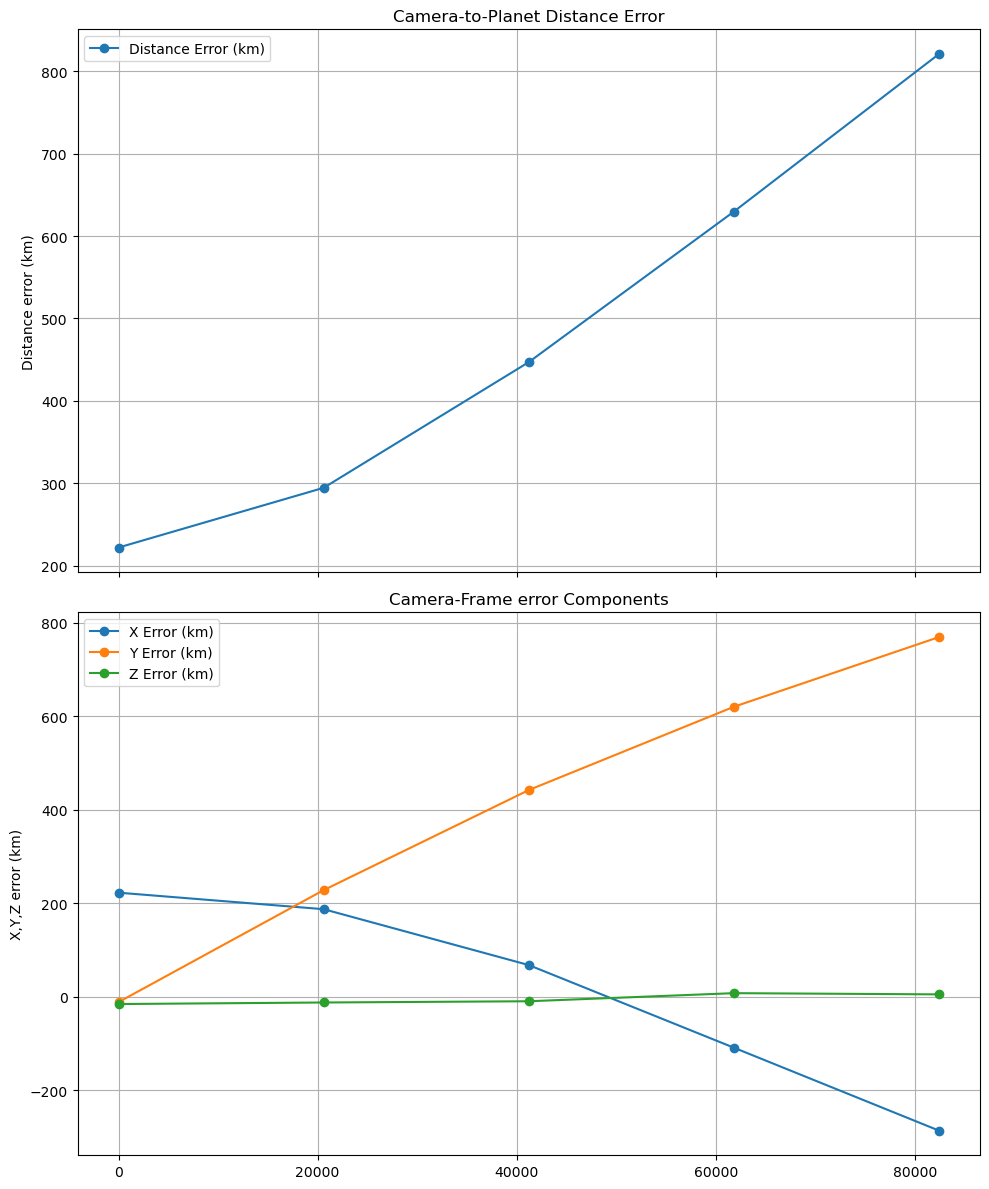

In [118]:
plot_est_dist_xyz_errors(
    times,
    pos,
    estimates,
)